# Fraud Detection Feature Engineering

## Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
warnings.filterwarnings("ignore")

## Load and Inspect Data

In [2]:
# Load dataset
df = pd.read_csv("simulated-data-raw1.csv")

# Initial inspection
print("First 5 rows:")
display(df.head())

print("\nRandom 10 rows:")
display(df.sample(10))

print("\nDataset info:\n")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

print("\nFraud distribution:")
display(df["TX_FRAUD"].value_counts())

print("\nFraud scenario distribution:")
display(df["TX_FRAUD_SCENARIO"].value_counts())

print("\nMissing values:")
display(df.isnull().sum())

First 5 rows:


,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,0,2024-04-01 00:00:31,596,1337,57.16,31,0,0,0
1,1,1,2024-04-01 00:07:56,2,523,146.00,476,0,0,0
2,2,2,2024-04-01 00:10:34,927,824,50.99,634,0,0,0
3,3,3,2024-04-01 00:10:45,568,4805,44.71,645,0,0,0
4,4,4,2024-04-01 00:13:44,541,3260,59.07,824,0,0,0



Random 10 rows:


,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
132085,132085,132085,2024-04-28 13:50:40,540,4923,33.21,2382640,27,0,0
59440,59440,59440,2024-04-13 11:18:29,1486,2475,24.75,1077509,12,0,0
255929,255929,255929,2024-05-24 11:23:33,1471,1114,42.23,4620213,53,0,0
58168,58168,58168,2024-04-13 07:19:07,1595,332,35.58,1063147,12,0,0
266719,266719,266719,2024-05-26 14:33:05,2185,2559,11.31,4804385,55,0,0
86313,86313,86313,2024-04-19 04:28:12,1042,1909,38.51,1571292,18,0,0
245408,245408,245408,2024-05-22 07:31:00,1499,1259,41.73,4433460,51,0,0
282998,282998,282998,2024-05-30 04:25:08,851,315,33.12,5113508,59,0,0
211765,211765,211765,2024-05-15 07:47:19,49,4799,19.82,3829639,44,0,0
260246,260246,260246,2024-05-25 09:55:07,394,4155,36.05,4701307,54,0,0



Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383087 entries, 0 to 383086
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         383087 non-null  int64  
 1   TRANSACTION_ID     383087 non-null  int64  
 2   TX_DATETIME        383087 non-null  object 
 3   CUSTOMER_ID        383087 non-null  int64  
 4   TERMINAL_ID        383087 non-null  int64  
 5   TX_AMOUNT          383087 non-null  float64
 6   TX_TIME_SECONDS    383087 non-null  int64  
 7   TX_TIME_DAYS       383087 non-null  int64  
 8   TX_FRAUD           383087 non-null  int64  
 9   TX_FRAUD_SCENARIO  383087 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 29.2+ MB

Descriptive statistics:


...

TX_FRAUD
0    377320
1      5767
Name: count, dtype: int64


Fraud scenario distribution:


TX_FRAUD_SCENARIO
0    377320
2      3681
3      1891
1       195
Name: count, dtype: int64


Missing values:


Unnamed: 0           0
TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64

## Feature Engineering

We will divide data in this project to three main categories:
1) Temporal Features
2) Customer Behavior Features
3) Terminal Usage Features

In [3]:
# Create a copy for transformations
df_transformed = df.copy(deep=True)

# Sort by customer and time for temporal features
df_transformed = df_transformed.sort_values(['CUSTOMER_ID', 'TX_TIME_SECONDS'])

# Convert to datetime
df_transformed['TX_DATETIME'] = pd.to_datetime(df_transformed['TX_DATETIME'])

### Temporal Features

In [ ]:
# Transactions in last hour features
df_transformed['TXs_LAST_1H'] = 0
df_transformed['AMOUNT_LAST_1H'] = 0.0


# Computing transcations(amount) in last hour using sliding window tequnique(for faster code)
def compute_rolling_features(group):
    tx_times = group['TX_TIME_SECONDS'].values
    tx_amounts = group['TX_AMOUNT'].values
    txs_last_1h = []
    amounts_last_1h = []

    start_idx = 0
    for i in range(len(group)):
        while tx_times[i] - tx_times[start_idx] > 3600:
            start_idx += 1
        window_len = i - start_idx + 1
        txs_last_1h.append(window_len)
        amounts_last_1h.append(tx_amounts[start_idx:i+1].sum())

    group['TXs_LAST_1H'] = txs_last_1h
    group['AMOUNT_LAST_1H'] = amounts_last_1h
    return group

# Apply per customer
df_transformed = df_transformed.groupby('CUSTOMER_ID', group_keys=False).apply(compute_rolling_features)

# Time-based features
df_transformed['TX_HOUR'] = df_transformed['TX_DATETIME'].dt.hour
df_transformed['TX_DAY'] = df_transformed['TX_DATETIME'].dt.dayofweek # Monday=0,...,Sunday=6
df_transformed['TX_IS_WEEKEND'] = (df_transformed['TX_DAY'] >= 5).astype(int)
df_transformed['TX_HOUR_CATEGORY'] = pd.cut(df_transformed['TX_HOUR'],
                                          bins=[0, 6, 12, 18, 24],
                                          labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                                          right=False)

# Time periods for aggregation
df_transformed['Week'] = df_transformed['TX_TIME_DAYS'] // 7
df_transformed['Month'] = df_transformed['TX_TIME_DAYS'] // 30

In [5]:
df_transformed.head()

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TXs_LAST_1H,AMOUNT_LAST_1H,TX_HOUR,TX_DAY,TX_IS_WEEKEND,TX_HOUR_CATEGORY,Week,Month
890,890,890,2024-04-01 07:19:05,0,2530,123.59,26345,0,0,0,1,123.59,7,2,0,Morning,0,0
4138,4138,4138,2024-04-01 18:00:16,0,144,77.34,64816,0,0,0,1,77.34,18,2,0,Evening,0,0
4319,4319,4319,2024-04-01 19:02:02,0,2636,46.51,68522,0,0,0,1,46.51,19,2,0,Evening,0,0
6082,6082,6082,2024-04-02 08:51:06,0,2575,54.72,118266,1,0,0,1,54.72,8,3,0,Morning,0,0
7903,7903,7903,2024-04-02 14:05:38,0,3028,63.30,137138,1,0,0,1,63.30,14,3,0,Afternoon,0,0


### Customer Behavior Features

In [6]:
# Customer transaction patterns
def calculate_avg_ratio(group):
    return (group['TX_AMOUNT'] / group['TX_AMOUNT'].mean()).round(2)

# Amount to average ratios
df_transformed['AMOUNT_TO_AVG'] = df_transformed.groupby('CUSTOMER_ID').apply(calculate_avg_ratio).reset_index(level=0, drop=True)
df_transformed['AMOUNT_TO_AVG_DAY'] = df_transformed.groupby(['CUSTOMER_ID', 'TX_TIME_DAYS']).apply(calculate_avg_ratio).reset_index(level=[0,1], drop=True)
df_transformed['AMOUNT_TO_AVG_WEEK'] = df_transformed.groupby(['CUSTOMER_ID', 'Week']).apply(calculate_avg_ratio).reset_index(level=[0,1], drop=True)
df_transformed['AMOUNT_TO_AVG_MONTH'] = df_transformed.groupby(['CUSTOMER_ID', 'Month']).apply(calculate_avg_ratio).reset_index(level=[0,1], drop=True)

# Customer standard deviation and z-score
def calculate_z_score(group):
    mean = group['TX_AMOUNT'].mean()
    std = group['TX_AMOUNT'].std()
    if std == 0:
        return pd.Series(0, index=group.index)
    return (group['TX_AMOUNT'] - mean) / std

df_transformed['CUSTOMER_STD'] = df_transformed.groupby('CUSTOMER_ID')['TX_AMOUNT'].transform('std').fillna(0).round(2)
df_transformed['Z_SCORE'] = df_transformed.groupby('CUSTOMER_ID').apply(calculate_z_score).reset_index(level=0, drop=True)
df_transformed['Z_SCORE'] = df_transformed['Z_SCORE'].replace([np.inf, -np.inf], np.nan).fillna(0).round(2)

# Customer frequency features
df_transformed['CUSTOMER_TX_FREQ'] = df_transformed.groupby('CUSTOMER_ID')['CUSTOMER_ID'].transform('count')
df_transformed['CUSTOMER_AVG_AMOUNT'] = df_transformed.groupby('CUSTOMER_ID')['TX_AMOUNT'].transform('mean')

# Time since last transaction
df_transformed['TIME_SINCE_LAST_TX'] = df_transformed.groupby('CUSTOMER_ID')['TX_TIME_SECONDS'].diff().fillna(-1)

### Terminal Usage Features

In [7]:
# Terminal usage patterns
df_transformed['NEW_TERMINAL_FLAG'] = df_transformed.groupby('CUSTOMER_ID')['TERMINAL_ID'].transform(
    lambda x: (x != x.shift()).astype(int)
)

# Multiple terminals in same hour/day
df_transformed['MULTI_TERMINAL_FLAG'] = (
    df_transformed.groupby(['CUSTOMER_ID', 'TX_HOUR', 'TX_DAY'])['TERMINAL_ID']
    .transform('nunique') >= 3
    ).astype(int)

# Terminal frequency features
df_transformed['TERMINAL_FREQ'] = df_transformed.groupby('TERMINAL_ID')['TERMINAL_ID'].transform('count')
df_transformed['CUSTOMER_TERMINAL_FREQ'] = df_transformed.groupby(['CUSTOMER_ID', 'TERMINAL_ID'])['TERMINAL_ID'].transform('count')

# Time since last terminal use
df_transformed = df_transformed.sort_values(['TERMINAL_ID', 'TX_TIME_SECONDS'])
df_transformed['TIME_SINCE_LAST_TERMINAL_USE'] = df_transformed.groupby('TERMINAL_ID')['TX_TIME_SECONDS'].diff().fillna(-1)

## Data Cleaning & Final Processing

Null values per column:
TRANSACTION_ID                  0
TX_DATETIME                     0
CUSTOMER_ID                     0
TERMINAL_ID                     0
TX_AMOUNT                       0
TX_TIME_SECONDS                 0
TX_TIME_DAYS                    0
TX_FRAUD                        0
TX_FRAUD_SCENARIO               0
TXs_LAST_1H                     0
AMOUNT_LAST_1H                  0
TX_HOUR                         0
TX_DAY                          0
TX_IS_WEEKEND                   0
TX_HOUR_CATEGORY                0
AMOUNT_TO_AVG                   0
AMOUNT_TO_AVG_DAY               0
AMOUNT_TO_AVG_WEEK              0
AMOUNT_TO_AVG_MONTH             0
CUSTOMER_STD                    0
Z_SCORE                         0
CUSTOMER_TX_FREQ                0
CUSTOMER_AVG_AMOUNT             0
TIME_SINCE_LAST_TX              0
NEW_TERMINAL_FLAG               0
MULTI_TERMINAL_FLAG             0
TERMINAL_FREQ                   0
CUSTOMER_TERMINAL_FREQ          0
TIME_SINCE_LAST_TERMINAL

TX_FRAUD                        1.000000
TX_FRAUD_SCENARIO               0.974465
AMOUNT_TO_AVG                   0.244089
TX_AMOUNT                       0.207711
AMOUNT_TO_AVG_MONTH             0.183507
AMOUNT_LAST_1H                  0.177497
Z_SCORE                         0.140596
AMOUNT_TO_AVG_WEEK              0.117954
CUSTOMER_STD                    0.079800
AMOUNT_TO_AVG_DAY               0.068287
TX_TIME_DAYS                    0.026666
TX_TIME_SECONDS                 0.026646
TRANSACTION_ID                  0.026632
CUSTOMER_AVG_AMOUNT             0.023305
TERMINAL_FREQ                   0.006327
TX_IS_WEEKEND                   0.002982
TX_DAY                          0.002654
TIME_SINCE_LAST_TX              0.002135
NEW_TERMINAL_FLAG               0.002129
TIME_SINCE_LAST_TERMINAL_USE    0.002074
MULTI_TERMINAL_FLAG            -0.000881
TXs_LAST_1H                    -0.001228
TX_HOUR                        -0.002056
CUSTOMER_TX_FREQ               -0.003271
CUSTOMER_ID     

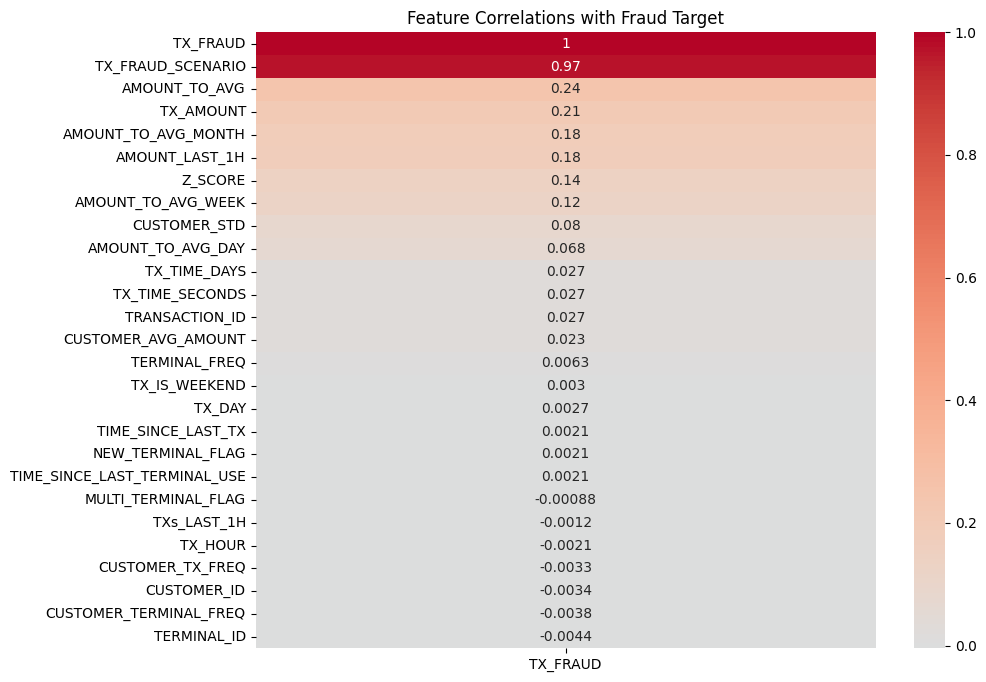

In [ ]:
# Downcast numeric columns to save memory
for col in df_transformed.select_dtypes(include=['int64']):
    df_transformed[col] = pd.to_numeric(df_transformed[col], downcast='integer')
    
for col in df_transformed.select_dtypes(include=['float64']):
    df_transformed[col] = pd.to_numeric(df_transformed[col], downcast='float')

# Drop unnecessary columns
columns_to_drop = ['Unnamed: 0', 'Week', 'Month']
df_transformed.drop(columns=[col for col in columns_to_drop if col in df_transformed.columns], inplace=True)

# Convert boolean flags to int
bool_cols = df_transformed.select_dtypes(include=['bool']).columns
df_transformed[bool_cols] = df_transformed[bool_cols].astype(int)

# Final validation checks
print("Null values per column:")
print(df_transformed.isnull().sum())

print("\nData types:")
print(df_transformed.dtypes)

## Save Transformed Data

In [9]:
# Save full transformed dataset
df_transformed.to_csv('simulated-data-transformed.csv', index=False)

# Save a sample for testing
df_transformed.sample(10000).to_csv('simulated-data-transformed-sample.csv', index=False)

print("Transformation complete. Data saved to:")
print("- simulated-data-transformed.csv")
print("- simulated-data-transformed-sample.csv")

Transformation complete. Data saved to:
- simulated-data-transformed.csv
- simulated-data-transformed-sample.csv
